# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# EDA. PREM500 Earth Model
---

## Physical Background

The **Preliminary Reference Earth Model (PREM)** is the standard radial reference model of the Earth's interior, published by Dziewonski & Anderson (*Phys. Earth Planet. Int.* **25**, 297–356, 1981). It describes a spherically symmetric, self-gravitating, non-rotating Earth in hydrostatic equilibrium, partitioned into **thirteen structural regions** separated by first-order discontinuities. Within each region, density $\rho$, the compressional ($V_P$) and shear ($V_S$) seismic wave velocities, the quality factors ($Q_\kappa$, $Q_\mu$), and the transverse-isotropy parameter $\eta$ are expressed as polynomials in the normalized radius $r/a$ ($a = 6371\,\mathrm{km}$, the mean Earth radius). PREM has been the international reference for global seismology for over four decades and is the model of choice in most large-scale geophysical and neutrino-physics calculations requiring an Earth-matter density profile.

**PREM500** is the standard tabulated representation of PREM sampled at 500 radial points, distributed to preserve the exact position of every documented discontinuity. It is obtained from the **IRIS SPUD Earth Model Repository** (Incorporated Research Institutions for Seismology, dataset ID 9785674), the canonical archive for community Earth models in global seismology.

The file contains nine columns per row, with rows ordered from the Earth's centre ($r = 0$) to its surface ($r = a$). Discontinuities are encoded by two consecutive rows that share the same radius value, giving the physical properties immediately below and above the interface:

| # | Column | Units | Physical quantity |
|---|--------|-------|------------------|
| 1 | `radius_m` | m | Radius from the Earth's centre |
| 2 | `density_kg_m3` | kg m⁻³ | Mass density $\rho(r)$ |
| 3 | `vpv_m_s` | m s⁻¹ | P-wave velocity, vertical polarisation $V_{PV}$ |
| 4 | `vsv_m_s` | m s⁻¹ | S-wave velocity, vertical polarisation $V_{SV}$ (zero in fluids) |
| 5 | `q_kappa` | — | Bulk (compressional) quality factor $Q_\kappa$ |
| 6 | `q_mu` | — | Shear quality factor $Q_\mu$ (zero where shear modulus vanishes) |
| 7 | `vph_m_s` | m s⁻¹ | P-wave velocity, horizontal polarisation $V_{PH}$ |
| 8 | `vsh_m_s` | m s⁻¹ | S-wave velocity, horizontal polarisation $V_{SH}$ |
| 9 | `eta` | — | Transverse anisotropy parameter $\eta = F/(A - 2L)$ |

## Relevance for Neutrino Oscillations

The propagation of neutrinos through the Earth is governed by the **MSW (Mikheyev–Smirnov–Wolfenstein) effect**, in which forward scattering of $\nu_e$ on electrons introduces a flavour-dependent matter potential

$$V_e(r) = \sqrt{2}\,G_F\,n_e(r),$$

where $G_F$ is the Fermi constant and $n_e(r)$ is the electron number density. The PREM tabulates mass density; the electron density is derived as

$$n_e\,[\mathrm{mol\,cm^{-3}}] = \left\langle\frac{Z}{A}\right\rangle(r) \cdot \rho\,[\mathrm{g\,cm^{-3}}],$$

where $\langle Z/A\rangle$ is the layer-averaged ratio of atomic number to mass number ($\approx 0.494$ for the silicate mantle and crust, $\approx 0.466$ for the iron-dominated core). This notebook checks the PREM500 file structure, identifies and labels the principal discontinuities, visualizes the density and velocity profiles, and derives the electron density profile that enters the MSW potential.

## 1. Libraries

The notebook uses the shared TPeanuts notebook configuration for paths, plotting style, device, and dtype. No repository or data paths are assembled manually here.

In [1]:
from __future__ import annotations

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.util.notebooks import save_and_show

## 2. Paths and Configuration

`load_notebook_config` centralizes the project paths and output directory handling. The PREM500 CSV is accessed through `config.prem500_file`.

In [2]:
config = load_notebook_config()

PREM_FILE = config.prem500_file
OUTPUT_DIR = config.output_dir("analysis", "external", "prem", "eda")
SHOW_PLOTS = config.show_plots

print(f"PREM500 file     : {PREM_FILE}")
print(f"Output directory : {OUTPUT_DIR}")
print(f"File exists      : {PREM_FILE.exists()}")

PREM500 file     : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\external\PREM500.csv
Output directory : v:\output\analysis\external\prem\eda
File exists      : True


## 3. Load PREM500

The downloaded table has no header. This section assigns explicit physical names, loads the CSV, and adds notebook-friendly derived columns for radius, depth, and density units.

### 3.1. Column Description

| Column | Description |
|---|---|
| `radius_m` | Radius from the Earth's centre, in metres. It increases from the centre toward the surface. |
| `density_kg_m3` | Mass density, in kg/m^3. |
| `vpv_m_s` | P-wave velocity for vertical/radial polarization, in m/s. |
| `vsv_m_s` | S-wave velocity for vertical/radial polarization, in m/s. Values can be zero in fluid layers. |
| `q_kappa` | Quality factor associated with bulk/compressional attenuation. |
| `q_mu` | Quality factor associated with shear attenuation. It is zero where the shear modulus is zero. |
| `vph_m_s` | P-wave velocity for horizontal/transverse polarization, in m/s. |
| `vsh_m_s` | S-wave velocity for horizontal/transverse polarization, in m/s. |
| `eta` | Radial anisotropy parameter in PREM. |
| `radius_km` | Derived column: `radius_m / 1000`, in km. |
| `earth_radius_km` | Derived column: maximum tabulated radius, used as the Earth-radius reference. |
| `depth_km` | Derived column: depth below the surface, `earth_radius_km - radius_km`. It is zero at the surface and largest at the centre. |
| `density_g_cm3` | Derived column: `density_kg_m3 / 1000`, in g/cm^3. |

In [3]:
PREM_COLUMNS = [
    "radius_m",
    "density_kg_m3",
    "vpv_m_s",
    "vsv_m_s",
    "q_kappa",
    "q_mu",
    "vph_m_s",
    "vsh_m_s",
    "eta",
]

prem = pd.read_csv(PREM_FILE, header=None, names=PREM_COLUMNS)

prem["radius_km"] = prem["radius_m"] / 1.0e3
prem["earth_radius_km"] = prem["radius_km"].max()
prem["depth_km"] = prem["earth_radius_km"] - prem["radius_km"]
prem["density_g_cm3"] = prem["density_kg_m3"] / 1.0e3

### 3.2. First Inspection

The following printout reports the table size and available columns, then displays the first and last rows to inspect the centre-to-surface ordering.

In [4]:
print(f"Rows    : {len(prem)}")
print(f"Columns : {list(prem.columns)}")
display(prem.head())
display(prem.tail())

Rows    : 504
Columns : ['radius_m', 'density_kg_m3', 'vpv_m_s', 'vsv_m_s', 'q_kappa', 'q_mu', 'vph_m_s', 'vsh_m_s', 'eta', 'radius_km', 'earth_radius_km', 'depth_km', 'density_g_cm3']


,radius_m,density_kg_m3,vpv_m_s,vsv_m_s,q_kappa,q_mu,vph_m_s,vsh_m_s,eta,radius_km,earth_radius_km,depth_km,density_g_cm3
0,0.0,13088.50,11262.20,3667.80,100000.0,104.0,11262.20,3667.80,1.0,0.000,6371.0,6371.000,13.08850
1,12858.0,13088.46,11262.17,3667.78,100000.0,104.0,11262.17,3667.78,1.0,12.858,6371.0,6358.142,13.08846
2,25716.0,13088.36,11262.10,3667.73,100000.0,104.0,11262.10,3667.73,1.0,25.716,6371.0,6345.284,13.08836
3,38574.0,13088.18,11261.97,3667.64,100000.0,104.0,11261.97,3667.64,1.0,38.574,6371.0,6332.426,13.08818
4,51432.0,13087.92,11261.79,3667.51,100000.0,104.0,11261.79,3667.51,1.0,51.432,6371.0,6319.568,13.08792


,radius_m,density_kg_m3,vpv_m_s,vsv_m_s,q_kappa,q_mu,vph_m_s,vsh_m_s,eta,radius_km,earth_radius_km,depth_km,density_g_cm3
499,6356000.0,2900.0,6800.0,3900.0,100000.0,300.0,6800.0,3900.0,1.0,6356.0,6371.0,15.0,2.90
500,6356000.0,2600.0,5800.0,3200.0,100000.0,300.0,5800.0,3200.0,1.0,6356.0,6371.0,15.0,2.60
501,6368000.0,2600.0,5800.0,3200.0,100000.0,300.0,5800.0,3200.0,1.0,6368.0,6371.0,3.0,2.60
502,6368000.0,1020.0,1450.0,0.0,100000.0,0.0,1450.0,0.0,1.0,6368.0,6371.0,3.0,1.02
503,6371000.0,1020.0,1450.0,0.0,100000.0,0.0,1450.0,0.0,1.0,6371.0,6371.0,0.0,1.02


## 4. Basic Diagnostics

The PREM500 table has 504 rows but only 492 unique radius values. The 12 duplicated radii correspond to the PREM first-order discontinuities: each duplicate pair encodes the physical properties immediately below and above that interface (e.g. the ≈ 4.34 g cm⁻³ density drop at the Core-Mantle Boundary at 3480 km). Mass density spans from 1.02 g cm⁻³ (seawater at the surface) to 13.09 g cm⁻³ (solid iron at the Earth's centre), and the radius column is strictly monotonically non-decreasing.

In [5]:
diagnostics = pd.Series(
    {
        "radius_min_km": prem["radius_km"].min(),
        "radius_max_km": prem["radius_km"].max(),
        "depth_min_km": prem["depth_km"].min(),
        "depth_max_km": prem["depth_km"].max(),
        "density_min_g_cm3": prem["density_g_cm3"].min(),
        "density_max_g_cm3": prem["density_g_cm3"].max(),
        "unique_radius_samples": prem["radius_m"].nunique(),
        "duplicate_radius_rows": len(prem) - prem["radius_m"].nunique(),
        "radius_monotonic_increasing": prem["radius_m"].is_monotonic_increasing,
    },
    name="value",
)

display(diagnostics.to_frame())
display(prem[PREM_COLUMNS].describe().T)

,value
radius_min_km,0.0
radius_max_km,6371.0
depth_min_km,0.0
depth_max_km,6371.0
density_min_g_cm3,1.02
density_max_g_cm3,13.0885
unique_radius_samples,492
duplicate_radius_rows,12
radius_monotonic_increasing,True


,count,mean,std,min,25%,50%,75%,max
radius_m,504.0,3.208821e+06,1.854815e+06,0.00000,1603263.750,3216936.000,4.810081e+06,6371000.00
density_kg_m3,504.0,8.538900e+03,3.713515e+03,1020.00000,4892.485,10302.965,1.194469e+04,13088.50
vpv_m_s,504.0,1.071652e+04,1.732499e+03,1450.00000,9491.445,11072.705,1.190366e+04,13716.62
vsv_m_s,504.0,3.559197e+03,2.895089e+03,0.00000,0.000,3656.925,6.570977e+03,7265.97
q_kappa,504.0,1.000000e+05,0.000000e+00,100000.00000,100000.000,100000.000,1.000000e+05,100000.00
q_mu,504.0,1.599563e+02,1.525792e+02,0.00000,0.000,104.000,3.550000e+02,355.00
vph_m_s,504.0,1.072274e+04,1.722720e+03,1450.00000,9491.445,11072.705,1.190366e+04,13716.62
vsh_m_s,504.0,3.562279e+03,2.896072e+03,0.00000,0.000,3656.925,6.570977e+03,7265.97
eta,504.0,9.981873e-01,1.107990e-02,0.90039,1.000,1.000,1.000000e+00,1.00


## 5. PREM Layer Boundaries

PREM defines thirteen structural regions bounded by first-order discontinuities. The table below collects every duplicate-radius pair and every density jump larger than 0.25 g cm⁻³, labelled with the standard geophysical boundary name. Key features:

- **Inner Core Boundary (ICB)** at 1221.5 km radius: the solid inner core transitions to the liquid outer core; density drops by ≈ 0.60 g cm⁻³ upward.
- **Core-Mantle Boundary (CMB)** at 3480 km: the largest density contrast in the Earth (Δρ ≈ −4.34 g cm⁻³), marking liquid iron against the silicate lower mantle.
- **660 km discontinuity** at 5701 km radius: ringwoodite → bridgmanite + ferropericlase phase transition; boundary of the lower mantle.
- **400 km discontinuity** at 5971 km radius: olivine → wadsleyite; top of the lower half of the transition zone.
- **Mohorovičić (Moho)** at 6346.6 km: crust–mantle boundary; density drops from 3.38 to 2.90 g cm⁻³.
- **Conrad discontinuity** at 6356 km: lower to upper crust; Δρ = −0.30 g cm⁻³.
- **Ocean floor** at 6368 km: upper crust to seawater; Δρ = −1.58 g cm⁻³.

In [6]:
PREM_BOUNDARIES = {
    1221.5: "Inner Core Boundary (ICB)",
    3480.0: "Core-Mantle Boundary (CMB)",
    3630.0: "D’’ layer base",
    5600.0: "Lower-mantle transition",
    5701.0: "660 km disc. — lower mantle / transition zone",
    5771.0: "Transition zone internal boundary (600 km)",
    5971.0: "400 km disc. — olivine → wadsleyite",
    6151.0: "LVZ base / upper mantle (220 km depth)",
    6291.0: "LID base (80 km depth)",
    6346.6: "Mohorovicić (Moho) — crust / mantle",
    6356.0: "Conrad disc. — lower / upper crust",
    6368.0: "Ocean floor",
}

prem_sorted = prem.sort_values("radius_m").reset_index(drop=True)
prem_sorted["delta_density_g_cm3"] = prem_sorted["density_g_cm3"].diff()
prem_sorted["delta_radius_km"] = prem_sorted["radius_km"].diff()

repeated_radius = prem_sorted[prem_sorted["radius_m"].duplicated(keep=False)].copy()
large_jumps = prem_sorted.loc[prem_sorted["delta_density_g_cm3"].abs() > 0.25].copy()

boundary_candidates = pd.concat([repeated_radius, large_jumps], ignore_index=True)
boundary_candidates = (
    boundary_candidates[
        ["radius_km", "depth_km", "density_g_cm3", "delta_density_g_cm3", "delta_radius_km"]
    ]
    .drop_duplicates()
    .sort_values(["radius_km", "density_g_cm3"])
    .reset_index(drop=True)
)

boundary_candidates["boundary"] = (
    boundary_candidates["radius_km"]
    .round(1)
    .map(PREM_BOUNDARIES)
    .fillna("—")
)

display(
    boundary_candidates[
        ["radius_km", "depth_km", "boundary", "density_g_cm3", "delta_density_g_cm3"]
    ].rename(columns={
        "radius_km": "Radius [km]",
        "depth_km": "Depth [km]",
        "boundary": "Boundary",
        "density_g_cm3": "ρ [g/cm³]",
        "delta_density_g_cm3": "Δρ [g/cm³]",
    })
)

,Radius [km],Depth [km],Boundary,ρ [g/cm³],Δρ [g/cm³]
0,1221.5,5149.5,Inner Core Boundary (ICB),12.16633,-0.59728
1,1221.5,5149.5,Inner Core Boundary (ICB),12.76361,-0.00681
2,3480.0,2891.0,Core-Mantle Boundary (CMB),5.56646,-4.33698
3,3480.0,2891.0,Core-Mantle Boundary (CMB),9.90344,-0.02047
4,3630.0,2741.0,D’’ layer base,5.49148,-0.00680
5,3630.0,2741.0,D’’ layer base,5.49148,0.00000
6,5600.0,771.0,Lower-mantle transition,4.44320,-0.00782
7,5600.0,771.0,Lower-mantle transition,4.44320,0.00000
8,5701.0,670.0,660 km disc. — lower mantle / transition zone,3.99212,-0.38862
9,5701.0,670.0,660 km disc. — lower mantle / transition zone,4.38074,-0.00901


## 6. Density Profile

Both panels show mass density $\rho$ as a function of radius (left, centre-to-surface) and depth below the surface (right). Coloured bands identify the main Earth layers; dashed lines mark the principal named discontinuities. The most conspicuous features are the large density drop at the **Core-Mantle Boundary** (CMB, 3480 km radius / 2891 km depth) and the smooth decline through the outer core. The inner core reaches a maximum density of ≈ 13.09 g cm⁻³ at the Earth's centre, while the surface ocean has ρ ≈ 1.02 g cm⁻³. The outer core shows a smooth, nearly linear density decrease from the CMB upward, consistent with a convecting liquid iron-nickel alloy in adiabatic self-compression.

Saved figure: v:\output\analysis\external\prem\eda\prem500_density_profile.png


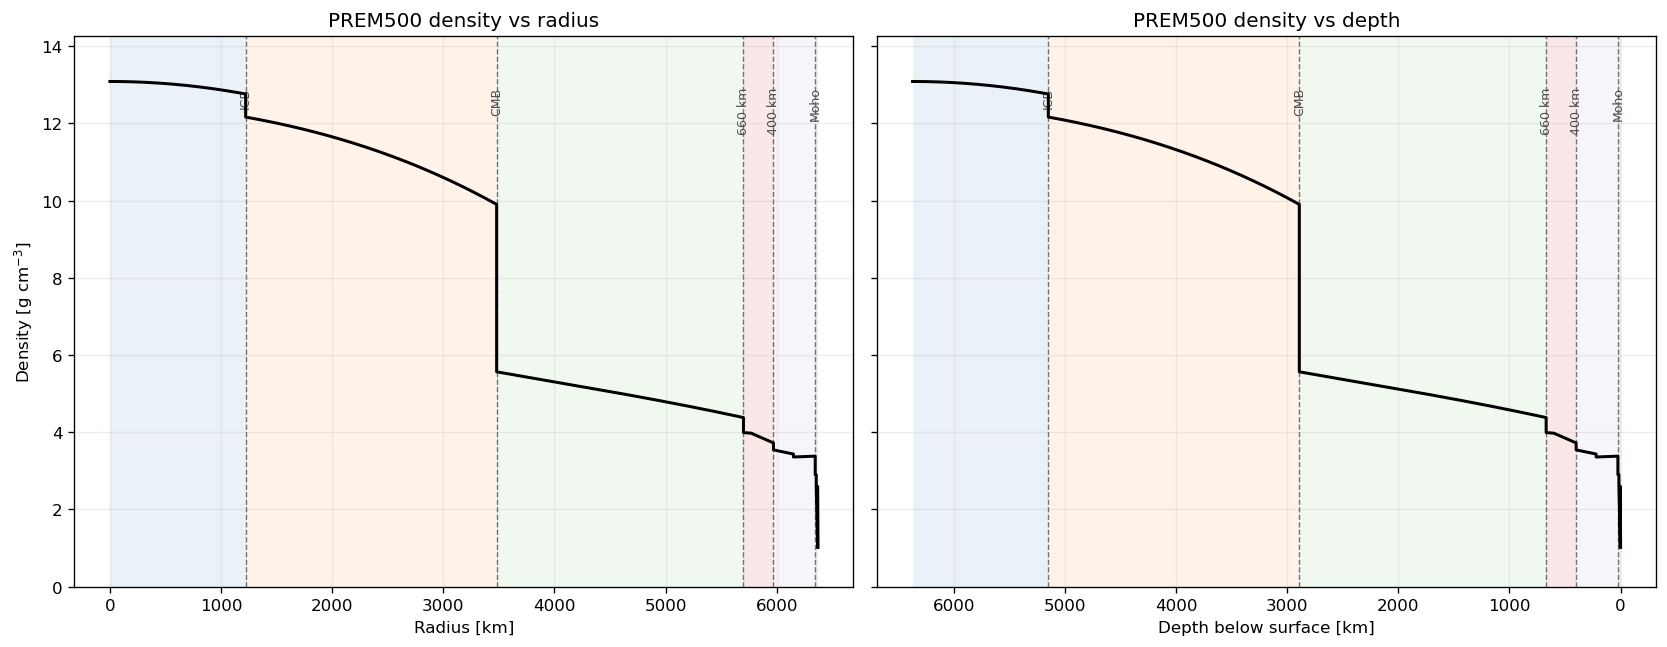

WindowsPath('v:/output/analysis/external/prem/eda/prem500_density_profile.png')

In [7]:
EARTH_LAYERS_R = [
    (0.0,     1221.5,  "C0", 0.09),
    (1221.5,  3480.0,  "C1", 0.09),
    (3480.0,  5701.0,  "C2", 0.07),
    (5701.0,  5971.0,  "C3", 0.10),
    (5971.0,  6346.6,  "C4", 0.07),
    (6346.6,  6371.0,  "C5", 0.11),
]

MAJOR_DISC_KM = [
    (1221.5, "ICB"),
    (3480.0, "CMB"),
    (5701.0, "660 km"),
    (5971.0, "400 km"),
    (6346.6, "Moho"),
]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.5), sharey=True)
rho_max = prem_sorted["density_g_cm3"].max()

# ---- Radius panel ----
ax = axes[0]
for r_lo, r_hi, color, alpha in EARTH_LAYERS_R:
    ax.axvspan(r_lo, r_hi, alpha=alpha, color=color, lw=0)
for r_km, label in MAJOR_DISC_KM:
    ax.axvline(r_km, color="0.45", lw=0.85, ls="--")
    ax.text(r_km, rho_max * 0.99, label, ha="center", va="top",
            fontsize=7.5, rotation=90, color="0.30")
ax.plot(prem_sorted["radius_km"], prem_sorted["density_g_cm3"], color="k", lw=1.8, zorder=5)
ax.set_xlabel("Radius [km]")
ax.set_ylabel(r"Density [g cm$^{-3}$]")
ax.set_title("PREM500 density vs radius")
ax.grid(True, alpha=0.22, zorder=1)
ax.set_ylim(0.0, rho_max * 1.09)

# ---- Depth panel ----
ax = axes[1]
for r_lo, r_hi, color, alpha in EARTH_LAYERS_R:
    d_lo = 6371.0 - r_hi
    d_hi = 6371.0 - r_lo
    ax.axvspan(d_lo, d_hi, alpha=alpha, color=color, lw=0)
for r_km, label in MAJOR_DISC_KM:
    d_km = 6371.0 - r_km
    ax.axvline(d_km, color="0.45", lw=0.85, ls="--")
    ax.text(d_km, rho_max * 0.99, label, ha="center", va="top",
            fontsize=7.5, rotation=90, color="0.30")
ax.plot(prem_sorted["depth_km"], prem_sorted["density_g_cm3"], color="k", lw=1.8, zorder=5)
ax.invert_xaxis()
ax.set_xlabel("Depth below surface [km]")
ax.set_title("PREM500 density vs depth")
ax.grid(True, alpha=0.22, zorder=1)

fig.tight_layout()
save_and_show("prem500_density_profile.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Seismic Velocity and Density Cross-Check

The dual-axis plot overlays mass density (left axis) with the vertically polarised P-wave velocity $V_{PV}$ and S-wave velocity $V_{SV}$ (right axis) along the same radial profile. Key observations:

- **$V_{SV} = 0$ in the outer core** (1221–3480 km): shear waves cannot propagate in a liquid, confirming the outer core is molten iron-nickel.
- **$V_{SV} = 0$ in the ocean layer** (6368–6371 km): seawater is also a fluid.
- **$V_{PV}$ is higher in the upper outer core than in the lower mantle** just above the CMB: the liquid iron alloy has an exceptionally high bulk modulus despite its relatively lower density compared with the solid inner core.
- Both velocity curves are continuous within each structural region but jump sharply at the ICB, CMB, and the main mantle discontinuities identified in Section 5.

Saved figure: v:\output\analysis\external\prem\eda\prem500_density_velocity_overview.png


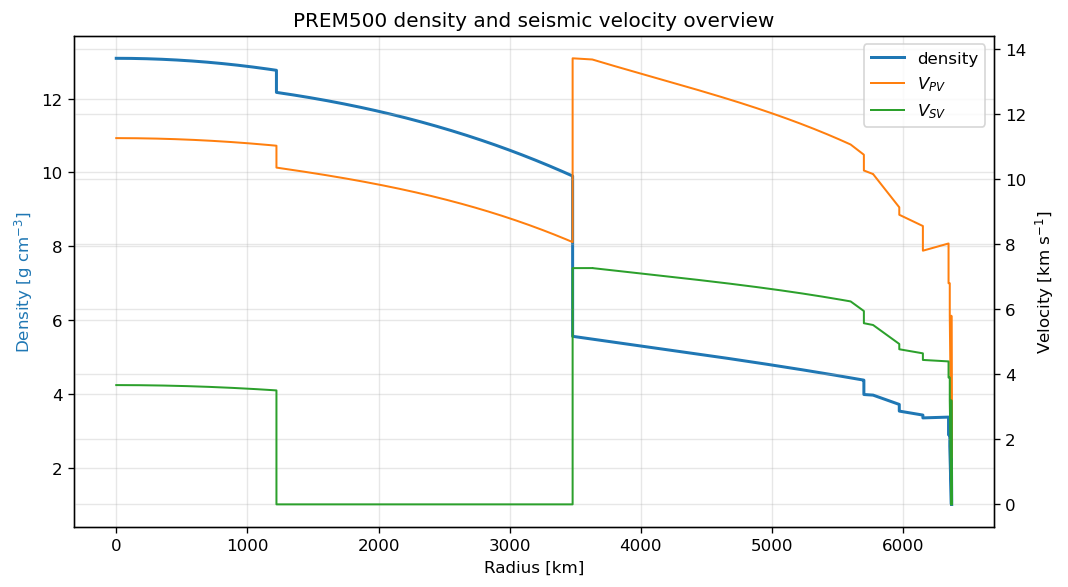

WindowsPath('v:/output/analysis/external/prem/eda/prem500_density_velocity_overview.png')

In [8]:
fig, ax_density = plt.subplots(figsize=(9.0, 5.0))
ax_velocity = ax_density.twinx()

ax_density.plot(prem_sorted["radius_km"], prem_sorted["density_g_cm3"], color="C0", lw=1.8, label="density")
ax_velocity.plot(prem_sorted["radius_km"], prem_sorted["vpv_m_s"] / 1.0e3, color="C1", lw=1.2, label=r"$V_{PV}$")
ax_velocity.plot(prem_sorted["radius_km"], prem_sorted["vsv_m_s"] / 1.0e3, color="C2", lw=1.2, label=r"$V_{SV}$")

ax_density.set_xlabel("Radius [km]")
ax_density.set_ylabel(r"Density [g cm$^{-3}$]", color="C0")
ax_velocity.set_ylabel(r"Velocity [km s$^{-1}$]")
ax_density.set_title("PREM500 density and seismic velocity overview")

lines_1, labels_1 = ax_density.get_legend_handles_labels()
lines_2, labels_2 = ax_velocity.get_legend_handles_labels()
ax_velocity.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
ax_density.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("prem500_density_velocity_overview.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 8. Electron Density for the MSW Potential

The physically relevant quantity for neutrino matter oscillations is the **electron number density** $n_e(r)$, not the mass density $\rho(r)$ tabulated in PREM. The conversion applies layer-appropriate $\langle Z/A\rangle$ values:

| Layer | Radius range [km] | Dominant composition | $\langle Z/A\rangle$ |
|-------|--------------------|---------------------|----------------------|
| Inner core | 0 – 1221.5 | Solid Fe–Ni (≈ 85 / 15 wt.) | 0.4656 |
| Outer core | 1221.5 – 3480 | Liquid Fe–Ni + light elements (O, S, Si) | 0.4678 |
| Mantle + crust | 3480 – 6368 | Silicates (MgSiO₃, Mg₂SiO₄, SiO₂, …) | 0.4940 |
| Ocean | 6368 – 6371 | Seawater (H₂O) | 0.5556 |

These $\langle Z/A\rangle$ values follow the standard assumptions used in the PREM-based electron-density literature (e.g. Freund & Ohlsson 2002, *Phys. Rev. D* **65**, 093012). The resulting profile is plotted as a function of normalized radius $r/R_E$ and depth; it is the profile that enters the MSW potential $V_e = \sqrt{2}\,G_F\,n_e$.

Electron density n_e (mol/cm³) at key boundaries:
  Earth centre         : 6.0940
  ICB  (inner side)    : 5.9427
  CMB  (mantle side)   : 4.6328
  400 km discontinuity : 1.8395
  Moho                 : 1.6701
  Surface (ocean)      : 0.5667
Saved figure: v:\output\analysis\external\prem\eda\prem500_electron_density.png


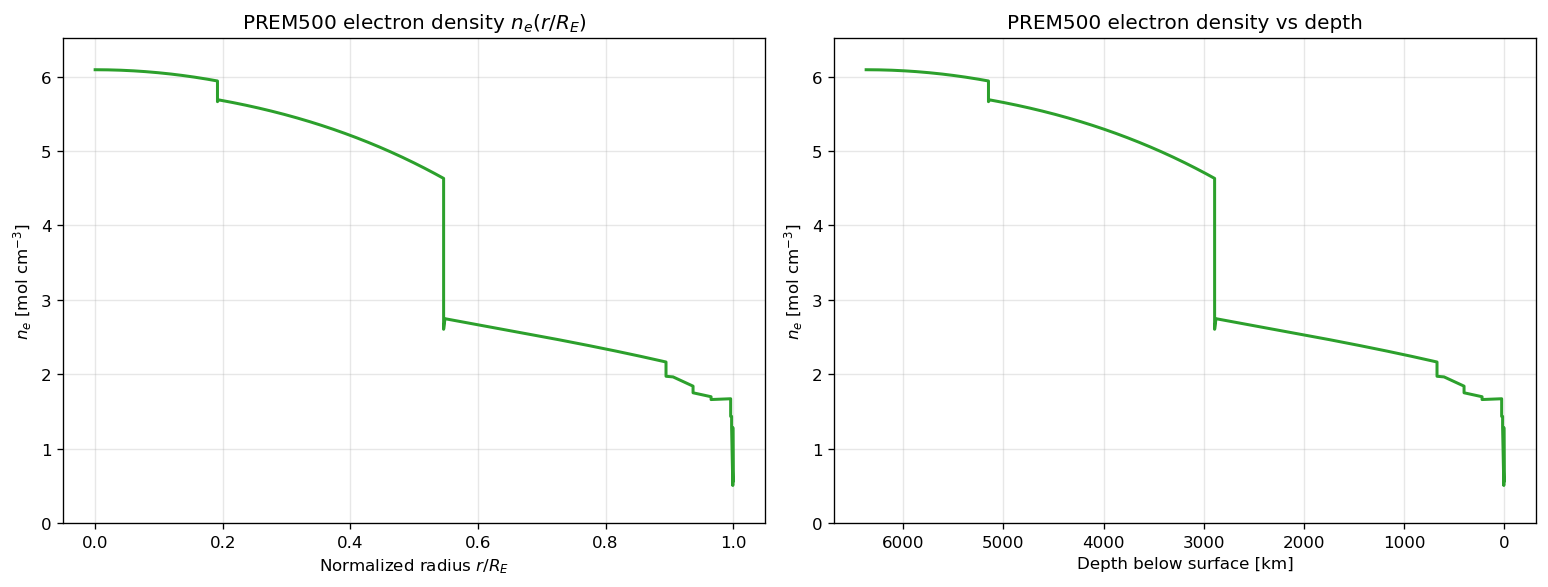

WindowsPath('v:/output/analysis/external/prem/eda/prem500_electron_density.png')

In [9]:
ZA_INNER_CORE   = 0.4656   # solid Fe-Ni: Fe(26/56) + Ni(28/58), ~85/15 wt ratio
ZA_OUTER_CORE   = 0.4678   # liquid Fe-Ni + light elements (O, S, Si)
ZA_MANTLE_CRUST = 0.4940   # silicate mantle and crust
ZA_OCEAN        = 0.5556   # seawater H2O (Z=10, A=18)

conditions = [
    prem_sorted["radius_km"] <= 1221.5,
    prem_sorted["radius_km"] <= 3480.0,
    prem_sorted["radius_km"] <= 6368.0,
]
za_values = [ZA_INNER_CORE, ZA_OUTER_CORE, ZA_MANTLE_CRUST]
prem_sorted["za_ratio"]    = np.select(conditions, za_values, default=ZA_OCEAN)
prem_sorted["ne_mol_cm3"]  = prem_sorted["za_ratio"] * prem_sorted["density_g_cm3"]
prem_sorted["radius_norm"] = prem_sorted["radius_km"] / prem_sorted["radius_km"].max()

print("Electron density n_e (mol/cm³) at key boundaries:")
for r_km_key, label in [
    (0.0,    "Earth centre         "),
    (1221.5, "ICB  (inner side)    "),
    (3480.0, "CMB  (mantle side)   "),
    (5971.0, "400 km discontinuity "),
    (6346.6, "Moho                 "),
    (6371.0, "Surface (ocean)      "),
]:
    rows = prem_sorted[prem_sorted["radius_km"].round(1) == r_km_key]
    if len(rows):
        val = rows["ne_mol_cm3"].max()
        print(f"  {label}: {val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))

axes[0].plot(prem_sorted["radius_norm"], prem_sorted["ne_mol_cm3"], color="C2", lw=1.8)
axes[0].set_xlabel(r"Normalized radius $r/R_E$")
axes[0].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[0].set_title(r"PREM500 electron density $n_e(r/R_E)$")
axes[0].set_ylim(0.0, prem_sorted["ne_mol_cm3"].max() * 1.07)
axes[0].grid(True, alpha=0.3)

axes[1].plot(prem_sorted["depth_km"], prem_sorted["ne_mol_cm3"], color="C2", lw=1.8)
axes[1].invert_xaxis()
axes[1].set_xlabel("Depth below surface [km]")
axes[1].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[1].set_title(r"PREM500 electron density vs depth")
axes[1].set_ylim(0.0, prem_sorted["ne_mol_cm3"].max() * 1.07)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("prem500_electron_density.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 9. Transverse Isotropy in the Upper Mantle

PREM incorporates **radial (transverse) anisotropy** in the depth range 24.4–220 km (the LID and LVZ layers, radius 6151–6346.6 km). In this zone the horizontal and vertical components of wave speed differ ($V_{SV} \neq V_{SH}$, $V_{PV} \neq V_{PH}$), encoded by the parameter $\eta \neq 1$. Throughout the rest of the Earth PREM is isotropic ($\eta = 1$). The anisotropy is attributed to the lattice-preferred orientation of olivine crystals under sub-lithospheric mantle flow. The left panel shows $\eta(r)$ over the full radial profile; the right panel overlays $V_{SV}$ and $V_{SH}$ to highlight the anisotropic zone. This feature does not enter the neutrino matter potential (which depends only on $\rho$), but it completes the PREM500 characterisation.

Saved figure: v:\output\analysis\external\prem\eda\prem500_anisotropy.png


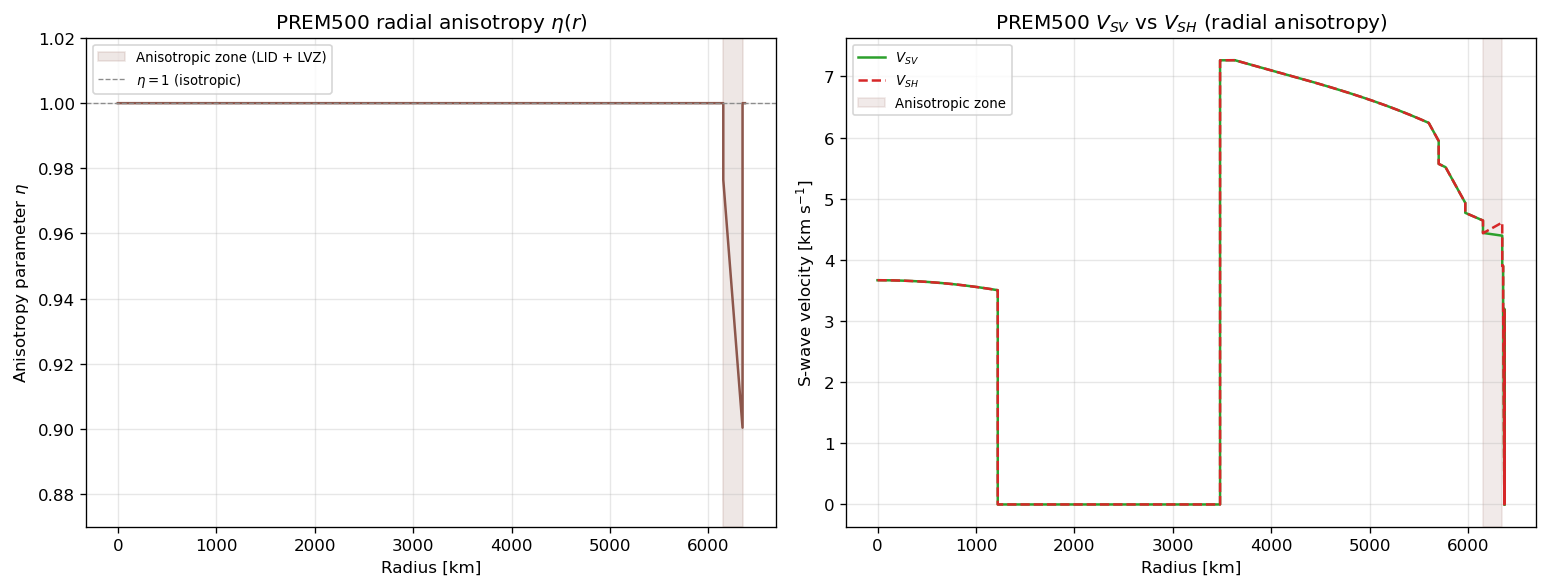

WindowsPath('v:/output/analysis/external/prem/eda/prem500_anisotropy.png')

In [10]:
aniso = prem_sorted[prem_sorted["eta"] != 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))

# --- eta profile ---
ax = axes[0]
ax.plot(prem_sorted["radius_km"], prem_sorted["eta"], color="C5", lw=1.5)
if not aniso.empty:
    ax.axvspan(aniso["radius_km"].min(), aniso["radius_km"].max(),
               alpha=0.14, color="C5", label="Anisotropic zone (LID + LVZ)")
ax.axhline(1.0, color="0.55", lw=0.8, ls="--", label=r"$\eta = 1$ (isotropic)")
ax.set_xlabel("Radius [km]")
ax.set_ylabel(r"Anisotropy parameter $\eta$")
ax.set_title(r"PREM500 radial anisotropy $\eta(r)$")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.87, 1.02)

# --- Vsv vs Vsh ---
ax = axes[1]
ax.plot(prem_sorted["radius_km"], prem_sorted["vsv_m_s"] / 1e3,
        color="C2", lw=1.5, label=r"$V_{SV}$")
ax.plot(prem_sorted["radius_km"], prem_sorted["vsh_m_s"] / 1e3,
        color="C3", lw=1.5, ls="--", label=r"$V_{SH}$")
if not aniso.empty:
    ax.axvspan(aniso["radius_km"].min(), aniso["radius_km"].max(),
               alpha=0.12, color="C5", label="Anisotropic zone")
ax.set_xlabel("Radius [km]")
ax.set_ylabel(r"S-wave velocity [km s$^{-1}$]")
ax.set_title(r"PREM500 $V_{SV}$ vs $V_{SH}$ (radial anisotropy)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("prem500_anisotropy.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 10. Compact Summary

Key numerical values extracted from PREM500, including the electron density profile derived in Section 8. These are reference numbers for verifying any downstream conversion of PREM into a density model for neutrino oscillation calculations.

In [11]:
summary = {
    "n_rows": len(prem_sorted),
    "unique_radii": prem_sorted["radius_m"].nunique(),
    "n_discontinuities": len(prem_sorted) - prem_sorted["radius_m"].nunique(),
    "earth_radius_km": prem_sorted["radius_km"].max(),
    "central_density_g_cm3": prem_sorted.iloc[0]["density_g_cm3"],
    "surface_density_g_cm3": prem_sorted.iloc[-1]["density_g_cm3"],
    "max_density_g_cm3": prem_sorted["density_g_cm3"].max(),
    "min_density_g_cm3": prem_sorted["density_g_cm3"].min(),
    "central_ne_mol_cm3": prem_sorted.iloc[0]["ne_mol_cm3"],
    "ne_cmb_mantle_mol_cm3": prem_sorted[prem_sorted["radius_km"] == 3480.0]["ne_mol_cm3"].max(),
    "ne_400km_disc_mol_cm3": prem_sorted[prem_sorted["radius_km"].round(0) == 5971]["ne_mol_cm3"].max(),
    "surface_ne_mol_cm3": prem_sorted.iloc[-1]["ne_mol_cm3"],
    "boundary_candidates": len(boundary_candidates),
}

for key, value in summary.items():
    print(f"{key:30s}: {value}")

n_rows                        : 504
unique_radii                  : 492
n_discontinuities             : 12
earth_radius_km               : 6371.0
central_density_g_cm3         : 13.0885
surface_density_g_cm3         : 1.02
max_density_g_cm3             : 13.0885
min_density_g_cm3             : 1.02
central_ne_mol_cm3            : 6.0940056
ne_cmb_mantle_mol_cm3         : 4.632829232
ne_400km_disc_mol_cm3         : 1.8395325
surface_ne_mol_cm3            : 0.566712
boundary_candidates           : 25
